# Dataset Overview & Foundation EDA

**IT5006 Group 9 · Milestone 1 · Olist Brazilian E-Commerce (2016–2018)**

This notebook is the shared foundation for every candidate problem the team explores. It covers the
four descriptive requirements of the Milestone 1 EDA deliverable — dataset overview, temporal
patterns, entity distributions, and correlation / relationship exploration — and then builds the
consolidated analysis table that notebooks `01`–`04` consume.

**Scope.** Descriptive analysis only. No model is fitted, no value is imputed and no train/test
split is made here; those belong to Phase 2.

| Section | Deliverable item it serves |
|---|---|
| 1. Setup and data loading | — |
| 2. Dataset overview | tables used, row counts, missing values |
| 3. How the tables join | joins, referential integrity |
| 4. Temporal patterns | order volume, seasonality |
| 5. Customer / seller / product distributions | entity distribution analysis |
| 6. Build the consolidated analysis table | reproducible input for `01`-`04` |
| 7. Correlation and relationship exploration | correlation, bivariate relationships |
| 8. Key insights | summary of patterns found |

**Reproducibility.** Everything below runs from the nine raw CSVs of the course archive. No
intermediate file produced elsewhere is required and no personal path is hard-coded.

## 1. Setup and data loading

The nine CSVs are expected in `data/Olist_CSV/` relative to the repository root. `data/` is
git-ignored, so each member unpacks the course archive there once. The loader also accepts an
explicit path through the `OLIST_CSV_DIR` environment variable and falls back to a Google Drive
mount under Colab, so the same file runs unchanged for everyone.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", "{:,.2f}".format)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 2.3.3 | numpy 2.3.5 | seaborn 0.13.2


In [2]:
def find_csv_dir():
    """Locate the folder holding the nine Olist CSVs, trying the usual places in order."""
    candidates = []
    if os.environ.get("OLIST_CSV_DIR"):
        candidates.append(Path(os.environ["OLIST_CSV_DIR"]))
    here = Path.cwd()
    candidates += [
        here / "data" / "Olist_CSV",                # run from the repository root
        here.parent / "data" / "Olist_CSV",         # run from notebooks/
        here / "data",
        here.parent / "data",
        Path("/content/drive/MyDrive/IT5006_Olist_Project/Olist_CSV"),   # Colab
        Path.home() / "Desktop" / "it5006" / "IT5006_Project-Data" / "Olist_CSV",
    ]
    for c in candidates:
        if (c / "olist_orders_dataset.csv").exists():
            return c
    raise FileNotFoundError(
        "Could not find the Olist CSVs. Unpack the course archive into data/Olist_CSV/ at the "
        "repository root, or set OLIST_CSV_DIR to the folder that holds them. Tried:\n  "
        + "\n  ".join(str(c) for c in candidates))


CSV_DIR = find_csv_dir()
print("Reading CSVs from:", CSV_DIR)

Reading CSVs from: /Users/ye.xueying/Desktop/it5006/IT5006-Group9-Olist-Project/data/Olist_CSV


In [3]:
FILES = {
    "orders":       "olist_orders_dataset.csv",
    "order_items":  "olist_order_items_dataset.csv",
    "products":     "olist_products_dataset.csv",
    "customers":    "olist_customers_dataset.csv",
    "sellers":      "olist_sellers_dataset.csv",
    "payments":     "olist_order_payments_dataset.csv",
    "reviews":      "olist_order_reviews_dataset.csv",
    "geolocation":  "olist_geolocation_dataset.csv",
    "category_tr":  "product_category_name_translation.csv",
}

DATE_COLS = {
    "orders": ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
               "order_delivered_customer_date", "order_estimated_delivery_date"],
    "order_items": ["shipping_limit_date"],
    "reviews": ["review_creation_date", "review_answer_timestamp"],
}

dfs = {name: pd.read_csv(CSV_DIR / fname) for name, fname in FILES.items()}
for name, cols in DATE_COLS.items():
    for c in cols:
        dfs[name][c] = pd.to_datetime(dfs[name][c])

orders, items, products, customers, sellers, payments, reviews, geo, cat_tr = (
    dfs["orders"], dfs["order_items"], dfs["products"], dfs["customers"], dfs["sellers"],
    dfs["payments"], dfs["reviews"], dfs["geolocation"], dfs["category_tr"])

print(f"Loaded {len(dfs)} tables, {sum(len(d) for d in dfs.values()):,} rows in total")

Loaded 9 tables, 1,550,922 rows in total


## 2. Dataset overview

### 2.1 Shape, memory, duplicates and missingness

In [4]:
overview = pd.DataFrame({
    "rows":             {k: len(v) for k, v in dfs.items()},
    "columns":          {k: v.shape[1] for k, v in dfs.items()},
    "memory_MB":        {k: v.memory_usage(deep=True).sum() / 1e6 for k, v in dfs.items()},
    "duplicate_rows":   {k: int(v.duplicated().sum()) for k, v in dfs.items()},
    "cells_missing_pct": {k: 100 * v.isna().sum().sum() / v.size for k, v in dfs.items()},
})
overview.round(2)

,rows,columns,memory_MB,duplicate_rows,cells_missing_pct
orders,99441,8,25.85,0,0.62
order_items,112650,7,30.98,0,0.00
products,32951,9,6.60,0,0.83
customers,99441,5,27.88,0,0.00
sellers,3095,4,0.62,0,0.00
payments,103886,5,17.02,0,0.00
reviews,99224,7,29.12,0,21.01
geolocation,1000163,5,135.67,261831,0.00
category_tr,71,2,0.01,0,0.00


**Observation.** `geolocation` is the only table with fully duplicated rows, and that is by design:
it stores one row per raw coordinate observation, not one row per zip prefix. No other table
contains exact duplicates.

In [5]:
grain = pd.DataFrame([
    ("orders",      "order_id",    orders.order_id.nunique(),     len(orders)),
    ("order_items", "order_id",    items.order_id.nunique(),      len(items)),
    ("products",    "product_id",  products.product_id.nunique(), len(products)),
    ("customers",   "customer_id", customers.customer_id.nunique(), len(customers)),
    ("sellers",     "seller_id",   sellers.seller_id.nunique(),   len(sellers)),
    ("payments",    "order_id",    payments.order_id.nunique(),   len(payments)),
    ("reviews",     "order_id",    reviews.order_id.nunique(),    len(reviews)),
], columns=["table", "key", "distinct_keys", "rows"])
grain["rows_per_key"] = (grain.rows / grain.distinct_keys).round(3)
grain

,table,key,distinct_keys,rows,rows_per_key
0,orders,order_id,99441,99441,1.00
1,order_items,order_id,98666,112650,1.14
2,products,product_id,32951,32951,1.00
3,customers,customer_id,99441,99441,1.00
4,sellers,seller_id,3095,3095,1.00
5,payments,order_id,99440,103886,1.04
6,reviews,order_id,98673,99224,1.01


`orders`, `products`, `customers` and `sellers` are one row per key. `order_items`, `payments` and
`reviews` are one-to-many against `order_id` and must be aggregated before any order-level join —
this is the single most common source of silently inflated row counts in this dataset.

### 2.2 Where the missing values are

In [6]:
miss = pd.concat([dfs[k].isna().mean().rename(k) for k in dfs], axis=1)
miss = (miss[miss.max(axis=1) > 0] * 100).round(2)
miss["worst_table"] = miss.idxmax(axis=1)
miss[["worst_table"] + [c for c in miss.columns if c != "worst_table"]].dropna(axis=1, how="all")

,worst_table,orders,products,reviews,category_tr
order_approved_at,orders,0.16,NaN,NaN,NaN
order_delivered_carrier_date,orders,1.79,NaN,NaN,NaN
order_delivered_customer_date,orders,2.98,NaN,NaN,NaN
product_category_name,products,NaN,1.85,NaN,0.00
product_name_lenght,products,NaN,1.85,NaN,NaN
product_description_lenght,products,NaN,1.85,NaN,NaN
product_photos_qty,products,NaN,1.85,NaN,NaN
product_weight_g,products,NaN,0.01,NaN,NaN
product_length_cm,products,NaN,0.01,NaN,NaN
product_height_cm,products,NaN,0.01,NaN,NaN


**Observation.** Missingness is confined to three tables and every case has a structural explanation.

- `reviews`: comment title ~88% and comment message ~59% empty — most customers rate without writing.
- `orders`: approval / carrier / customer-delivery timestamps are null exactly when an order never
  reached that stage (cancelled, unavailable, still shipping). These are **not** data errors, and
  `order_delivered_customer_date` being null is the reason the delivery cohort is smaller than the
  order count.
- `products`: category name and the description/photo attributes are missing for a small share of
  products.

No imputation is performed here. Milestone 2 must state, per model, whether a row with a missing
predictor is dropped or filled.

## 3. How the tables join

The schema is a star around `orders`. Every join used anywhere in this project is declared and
checked below, in both directions: what share of child rows find a parent, and what share of orders
have a child at all.

```text
                        products ── category_translation
                            │
customers ── orders ── order_items ── sellers
                │  │
                │  ├── payments
                │  └── reviews
             (zip prefix) ── geolocation
```

In [7]:
def link_check(label, child, child_key, parent, parent_key):
    matched = child[child_key].isin(parent[parent_key])
    return {"relationship": label, "child_rows": len(child),
            "matched_pct": round(100 * matched.mean(), 4),
            "unmatched_rows": int((~matched).sum())}


integrity = pd.DataFrame([
    link_check("order_items.order_id -> orders",        items, "order_id", orders, "order_id"),
    link_check("order_items.product_id -> products",    items, "product_id", products, "product_id"),
    link_check("order_items.seller_id -> sellers",      items, "seller_id", sellers, "seller_id"),
    link_check("orders.customer_id -> customers",       orders, "customer_id", customers, "customer_id"),
    link_check("payments.order_id -> orders",           payments, "order_id", orders, "order_id"),
    link_check("reviews.order_id -> orders",            reviews, "order_id", orders, "order_id"),
    link_check("customers.zip -> geolocation",          customers, "customer_zip_code_prefix",
               geo, "geolocation_zip_code_prefix"),
    link_check("sellers.zip -> geolocation",            sellers, "seller_zip_code_prefix",
               geo, "geolocation_zip_code_prefix"),
])
integrity

,relationship,child_rows,matched_pct,unmatched_rows
0,order_items.order_id -> orders,112650,100.00,0
1,order_items.product_id -> products,112650,100.00,0
2,order_items.seller_id -> sellers,112650,100.00,0
3,orders.customer_id -> customers,99441,100.00,0
4,payments.order_id -> orders,103886,100.00,0
5,reviews.order_id -> orders,99224,100.00,0
6,customers.zip -> geolocation,99441,99.72,278
7,sellers.zip -> geolocation,3095,99.77,7


In [8]:
coverage = pd.DataFrame({
    "has_items":    orders.order_id.isin(items.order_id),
    "has_payment":  orders.order_id.isin(payments.order_id),
    "has_review":   orders.order_id.isin(reviews.order_id),
})
cov = pd.DataFrame({
    "orders_with": coverage.sum(),
    "pct": (100 * coverage.mean()).round(2),
    "orders_without": (~coverage).sum(),
})
cov

,orders_with,pct,orders_without
has_items,98666,99.22,775
has_payment,99440,100.00,1
has_review,98673,99.23,768


**The 775 orders with no line item.** These are the only real referential gap and they explain why
the consolidated table has fewer orders than `orders`. They are almost all `unavailable` or
`canceled`, yet they were paid for and reviewed — poorly. They are excluded from the item-grain
table by construction, so any order-level rate computed on that table is conditional on
"order had at least one line item".

In [9]:
no_items = orders[~orders.order_id.isin(items.order_id)].copy()
paid = payments[payments.order_id.isin(no_items.order_id)].groupby("order_id").payment_value.sum()
rated = reviews[reviews.order_id.isin(no_items.order_id)].review_score

print(f"Orders with no line item : {len(no_items):,} ({len(no_items)/len(orders):.2%} of all orders)")
print(f"  total paid             : R$ {paid.sum():,.0f}")
print(f"  mean review score      : {rated.mean():.2f}  (n={len(rated):,})")
print()
print(no_items.order_status.value_counts().rename("orders").to_frame())

Orders with no line item : 775 (0.78% of all orders)
  total paid             : R$ 162,592
  mean review score      : 1.73  (n=759)

              orders
order_status        
unavailable      603
canceled         164
created            5
invoiced           2
shipped            1


## 4. Temporal patterns

Order volume, seasonality and how delivery performance moves over time. The window runs from
September 2016 to October 2018, but the two ends are thin: the platform was ramping up in late 2016
and the last weeks of the extract are truncated. Both edges are marked rather than silently dropped.

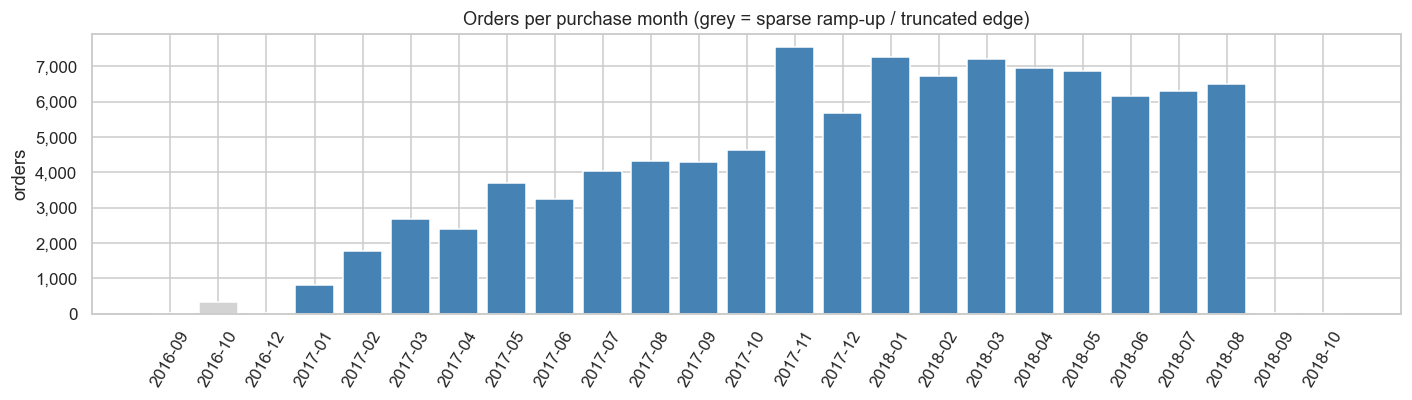

purchase_month
2016-09      4
2016-10    324
2016-12      1
2017-01    800
Freq: M
...
purchase_month
2018-08    6512
2018-09      16
2018-10       4
Freq: M


In [10]:
orders["purchase_month"] = orders.order_purchase_timestamp.dt.to_period("M")
monthly = orders.groupby("purchase_month").size().rename("orders")

fig, ax = plt.subplots(figsize=(13, 3.8))
colors = ["lightgray" if (m.year == 2016 or str(m) == "2018-09" or str(m) == "2018-10") else "steelblue"
          for m in monthly.index]
ax.bar(monthly.index.astype(str), monthly.values, color=colors)
ax.set_title("Orders per purchase month (grey = sparse ramp-up / truncated edge)")
ax.set_ylabel("orders"); ax.tick_params(axis="x", rotation=60)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

print(monthly.head(4).to_string())
print("...")
print(monthly.tail(3).to_string())

**Observation.** Volume grows about ninefold between January 2017 (789 orders) and the November
2017 peak (7,451 orders). The single largest month is November 2017 (Black Friday). Because that peak appears **once**, it cannot be learned as a seasonal
component from this data — any Phase 2 time-aware model must treat it as an event dummy rather than
as a recurring November effect.

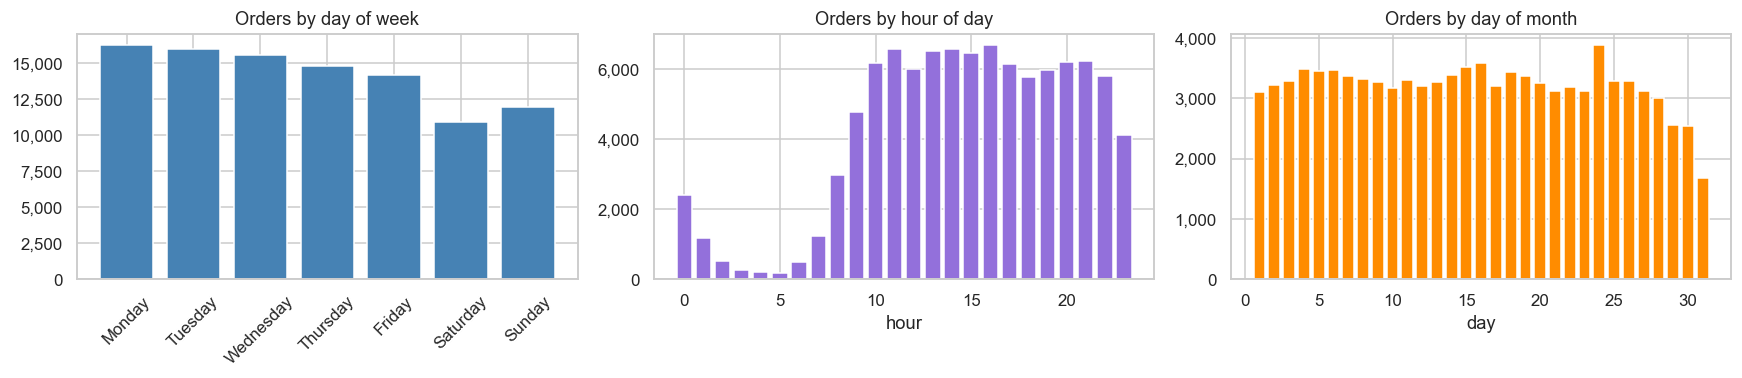

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))

dow = (orders.order_purchase_timestamp.dt.day_name()
       .value_counts()
       .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]))
axes[0].bar(dow.index, dow.values, color="steelblue")
axes[0].set_title("Orders by day of week"); axes[0].tick_params(axis="x", rotation=45)

hour = orders.order_purchase_timestamp.dt.hour.value_counts().sort_index()
axes[1].bar(hour.index, hour.values, color="mediumpurple")
axes[1].set_title("Orders by hour of day"); axes[1].set_xlabel("hour")

dom = orders.order_purchase_timestamp.dt.day.value_counts().sort_index()
axes[2].bar(dom.index, dom.values, color="darkorange")
axes[2].set_title("Orders by day of month"); axes[2].set_xlabel("day")

for a in axes:
    a.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

**Observation.** Weekdays carry clearly more volume than weekends, with a Monday peak, and ordering
concentrates in two daily windows (late morning and 20:00–22:00). Both are cheap, leakage-free
features available at purchase time.

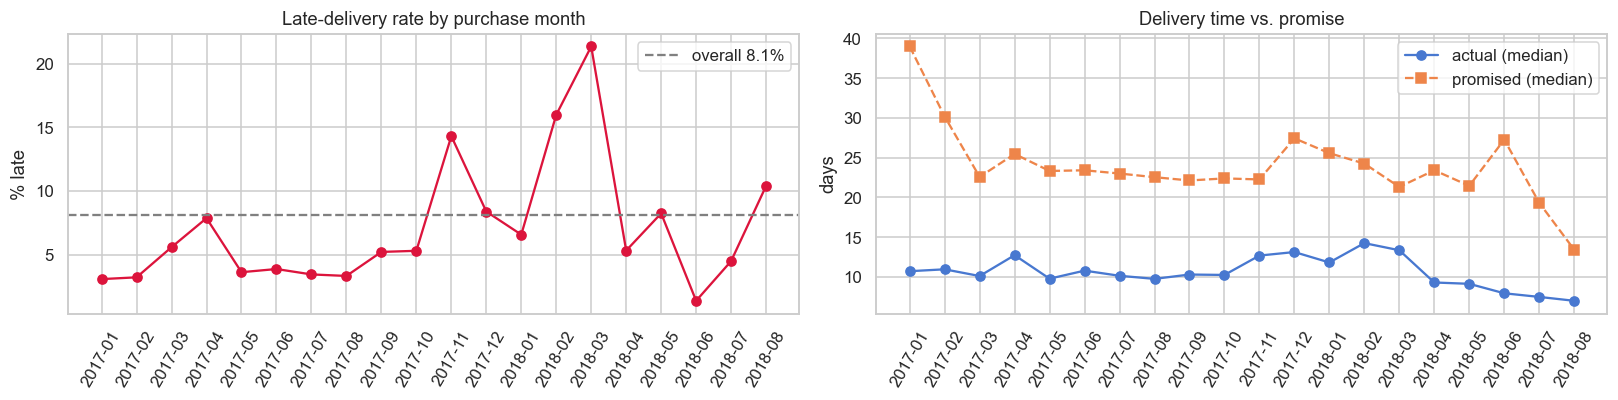

Delivered orders: 96,478 | overall late rate 8.11%
Median delivery 10.22 d | median promise 23.23 d | median slack 11.95 d


In [12]:
delivered = orders[orders.order_status == "delivered"].copy()
delivered["delivery_days"] = (delivered.order_delivered_customer_date
                              - delivered.order_purchase_timestamp).dt.total_seconds() / 86400
delivered["promised_days"] = (delivered.order_estimated_delivery_date
                              - delivered.order_purchase_timestamp).dt.total_seconds() / 86400
delivered["delay_days"] = (delivered.order_delivered_customer_date
                           - delivered.order_estimated_delivery_date).dt.total_seconds() / 86400
delivered["is_late"] = delivered.delay_days > 0

m = delivered.groupby("purchase_month").agg(
    orders=("order_id", "size"),
    late_rate=("is_late", "mean"),
    median_delivery=("delivery_days", "median"),
    median_promise=("promised_days", "median"),
)
m = m[m.orders >= 500]

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
axes[0].plot(m.index.astype(str), 100 * m.late_rate, marker="o", color="crimson")
axes[0].axhline(100 * delivered.is_late.mean(), ls="--", color="gray",
                label=f"overall {100 * delivered.is_late.mean():.1f}%")
axes[0].set_title("Late-delivery rate by purchase month"); axes[0].set_ylabel("% late")
axes[0].legend(); axes[0].tick_params(axis="x", rotation=60)

axes[1].plot(m.index.astype(str), m.median_delivery, marker="o", label="actual (median)")
axes[1].plot(m.index.astype(str), m.median_promise, marker="s", ls="--", label="promised (median)")
axes[1].set_title("Delivery time vs. promise"); axes[1].set_ylabel("days")
axes[1].legend(); axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

print(f"Delivered orders: {len(delivered):,} | overall late rate {delivered.is_late.mean():.2%}")
print(f"Median delivery {delivered.delivery_days.median():.2f} d | median promise "
      f"{delivered.promised_days.median():.2f} d | median slack "
      f"{(delivered.promised_days - delivered.delivery_days).median():.2f} d")

**Observation.** The late-delivery rate is wildly unstable in time. Among months with at least 500
delivered orders it ranges from 1.4% (June 2018) to 21.4% (March 2018) — a fifteen-fold spread —
while the promised lead time stays broadly flat. The promise
is therefore not being re-calibrated when operations degrade, which is precisely the gap a
late-delivery classifier would address. Purchase month is a strong candidate feature and, more
importantly, the instability means a **time-ordered** validation split is required in Phase 2; a
random split would leak the calm months into the test set.

## 5. Customer, seller and product distributions

### 5.1 Customers

`customer_id` is regenerated for every order and does **not** identify a person. `customer_unique_id`
does. Any customer-level statement in this project uses the latter.

customer_id rows (one per order) : 99,441
customer_unique_id (real people) : 96,096
Customers with more than 1 order : 2,997 (3.12%)
Max orders by one person         : 17


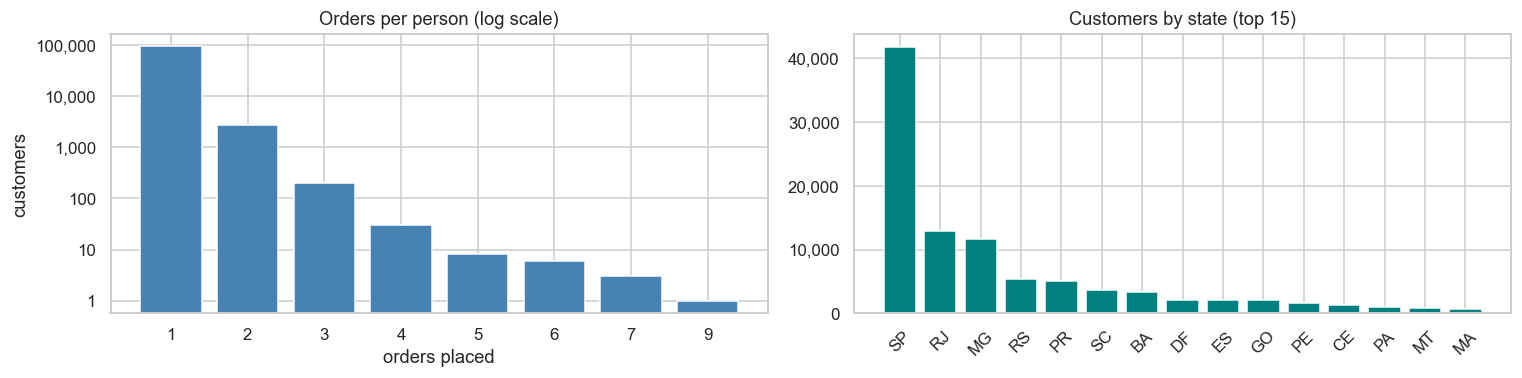


SP alone holds 42.0% of customers; the top 3 states hold 66.6%


In [13]:
per_person = customers.groupby("customer_unique_id").size()
print(f"customer_id rows (one per order) : {customers.customer_id.nunique():,}")
print(f"customer_unique_id (real people) : {customers.customer_unique_id.nunique():,}")
print(f"Customers with more than 1 order : {(per_person > 1).sum():,} ({(per_person > 1).mean():.2%})")
print(f"Max orders by one person         : {per_person.max()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
vc = per_person.value_counts().sort_index().head(8)
axes[0].bar(vc.index.astype(str), vc.values, color="steelblue")
axes[0].set_yscale("log"); axes[0].set_title("Orders per person (log scale)")
axes[0].set_xlabel("orders placed"); axes[0].set_ylabel("customers")

state_cust = customers.customer_state.value_counts()
axes[1].bar(state_cust.index[:15], state_cust.values[:15], color="teal")
axes[1].set_title("Customers by state (top 15)"); axes[1].tick_params(axis="x", rotation=45)
for a in axes:
    a.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

print(f"\nSP alone holds {state_cust.iloc[0] / state_cust.sum():.1%} of customers; "
      f"the top 3 states hold {state_cust.iloc[:3].sum() / state_cust.sum():.1%}")

**Observation.** Repeat buying is rare — about 3% of people order more than once — so this dataset
cannot support churn, CLV or repeat-purchase modelling with any confidence. That rules out a whole
family of otherwise attractive candidate problems, which is itself a useful Milestone 1 finding.
Geography is heavily concentrated in the south-east.

### 5.2 Sellers

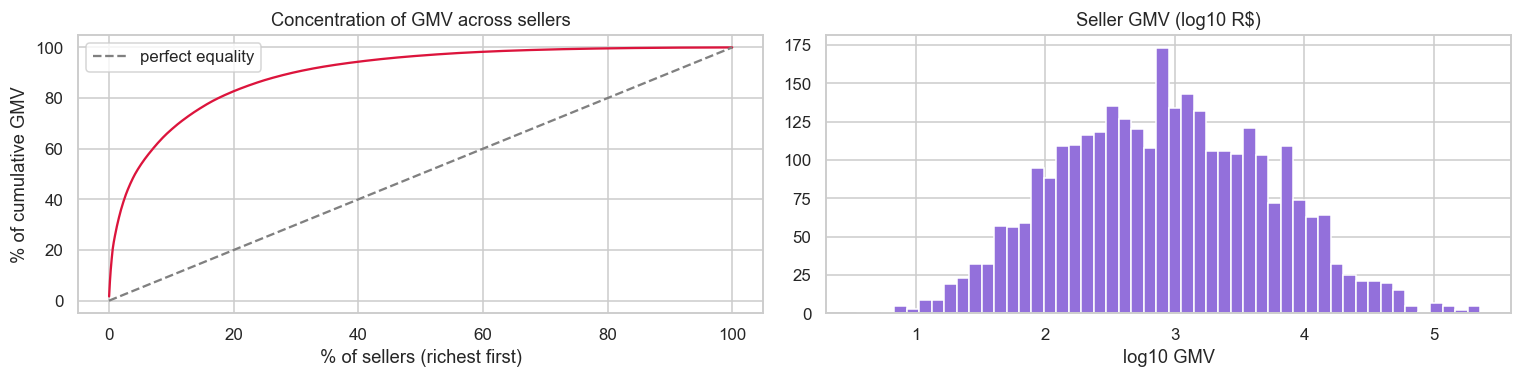

Sellers: 3,095
130 sellers (4.2%) produce half of all GMV
Median seller: 6 orders, R$ 821 GMV


In [14]:
seller_stats = (items.groupby("seller_id")
                .agg(orders=("order_id", "nunique"), items=("order_item_id", "size"),
                     gmv=("price", "sum"))
                .sort_values("gmv", ascending=False))

share = seller_stats.gmv.cumsum() / seller_stats.gmv.sum()
n_for_half = int((share <= 0.5).sum()) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
axes[0].plot(np.arange(1, len(share) + 1) / len(share) * 100, share.values * 100, color="crimson")
axes[0].plot([0, 100], [0, 100], ls="--", color="gray", label="perfect equality")
axes[0].set_title("Concentration of GMV across sellers")
axes[0].set_xlabel("% of sellers (richest first)"); axes[0].set_ylabel("% of cumulative GMV")
axes[0].legend()

axes[1].hist(np.log10(seller_stats.gmv.clip(lower=1)), bins=50, color="mediumpurple")
axes[1].set_title("Seller GMV (log10 R$)"); axes[1].set_xlabel("log10 GMV")
plt.tight_layout(); plt.show()

print(f"Sellers: {len(seller_stats):,}")
print(f"{n_for_half:,} sellers ({n_for_half/len(seller_stats):.1%}) produce half of all GMV")
print(f"Median seller: {seller_stats.orders.median():.0f} orders, R$ {seller_stats.gmv.median():,.0f} GMV")

**Observation.** GMV is extremely concentrated: a small minority of sellers produces half the
revenue while the median seller handles a handful of orders. Any seller-level feature therefore has
a very long tail of tiny-sample sellers, and target-encoding a seller id in Phase 2 would overfit
badly without smoothing.

### 5.3 Products

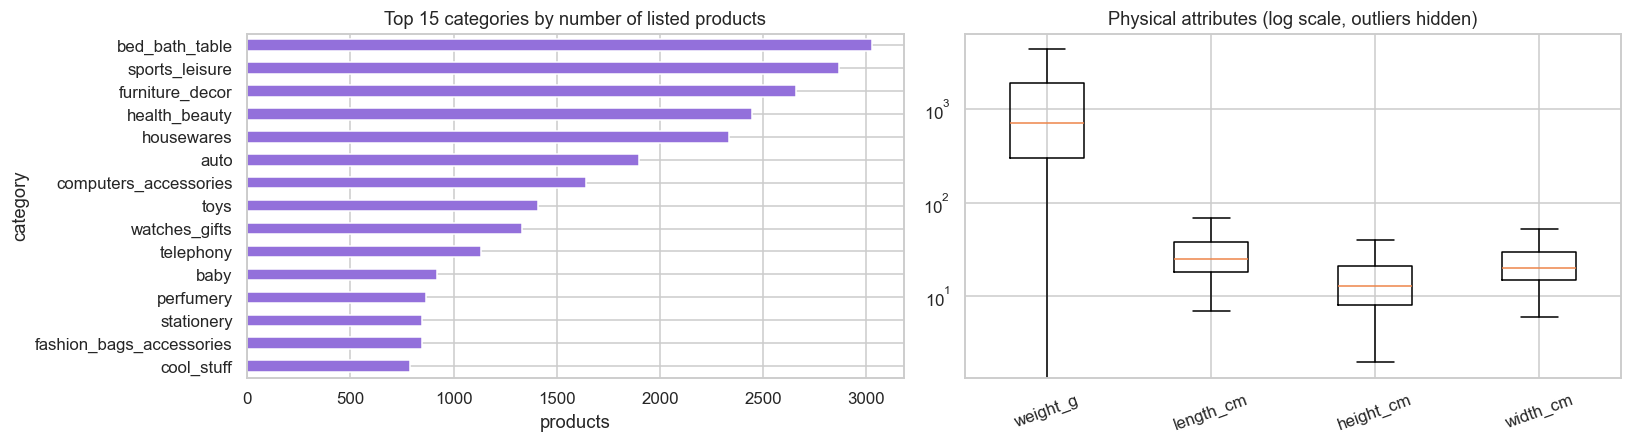

Distinct categories        : 73
Products with no category  : 610 (1.85%)
Top 10 categories cover    : 64.1% of products


In [15]:
prod = products.merge(cat_tr, on="product_category_name", how="left")
prod["category"] = prod.product_category_name_english.fillna(prod.product_category_name)

cat_counts = prod.category.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
cat_counts.head(15).iloc[::-1].plot.barh(ax=axes[0], color="mediumpurple")
axes[0].set_title("Top 15 categories by number of listed products"); axes[0].set_xlabel("products")

num_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
axes[1].boxplot([prod[c].dropna() for c in num_cols], labels=[c.replace("product_", "") for c in num_cols],
                showfliers=False)
axes[1].set_yscale("log"); axes[1].set_title("Physical attributes (log scale, outliers hidden)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

print(f"Distinct categories        : {prod.category.nunique()}")
print(f"Products with no category  : {prod.category.isna().sum():,} ({prod.category.isna().mean():.2%})")
print(f"Top 10 categories cover    : {cat_counts.head(10).sum() / cat_counts.sum():.1%} of products")

**Observation.** The category variable is long-tailed: 70+ categories, of which the top ten cover
about two thirds of the catalogue. Rare categories will need grouping into an `other` bucket before one-hot
encoding in Phase 2. Physical attributes span several orders of magnitude, so a log transform is the
natural starting point for any distance- or scale-sensitive model.

## 6. Build the consolidated analysis table

Notebooks `01`–`04` all work from one wide table at **order-item grain** (one row per line item).
It is built here so that the whole chain is reproducible from the raw archive; previously the file
was produced ad hoc and shared through Google Drive, which meant nobody else could regenerate it.

**Grain.** One row per `(order_id, order_item_id)` — 112,650 rows, matching `order_items` exactly.
Orders without a line item (the 775 from Section 3) are not represented. Aggregating to order grain
is the caller's job; the helper at the end of this section does it consistently.

**Aggregation rules that need stating**

- `payment_total` sums all payment rows of the order; `n_payment_methods` counts distinct payment
  types; `main_payment_type` is the type of the single largest payment.
- Where an order carries more than one review, the review with the latest
  `(review_creation_date, review_answer_timestamp, review_id)` wins. The rule is arbitrary but
  deterministic, which the previous ad hoc build was not.
- Coordinates are the mean of all `geolocation` rows sharing a zip prefix; `distance_km` is the
  great-circle distance between customer and seller zip centroids, rounded to 0.1 km.
- The product category is left `NaN` when unknown rather than filled with a string, so that the
  missingness stays visible to `isna()`.

In [16]:
# --- product category, in English where a translation exists -------------------------------
prod_cat = products.merge(cat_tr, on="product_category_name", how="left")

# --- payments, aggregated to one row per order ---------------------------------------------
pay_order = payments.groupby("order_id").agg(
    payment_total=("payment_value", "sum"),
    payment_max_installments=("payment_installments", "max"),
    n_payment_methods=("payment_type", "nunique"),
)
main_payment = (payments.sort_values("payment_value", ascending=False)
                .drop_duplicates("order_id")[["order_id", "payment_type"]]
                .rename(columns={"payment_type": "main_payment_type"}))

# --- reviews, one deterministic row per order ----------------------------------------------
rev_order = (reviews
             .sort_values(["review_creation_date", "review_answer_timestamp", "review_id"],
                          kind="stable")
             .drop_duplicates("order_id", keep="last")
             .assign(has_review_comment=lambda d: d.review_comment_message.notna(),
                     is_low_review=lambda d: d.review_score <= 2)
             [["order_id", "review_score", "review_creation_date", "review_answer_timestamp",
               "has_review_comment", "is_low_review"]])

# --- one coordinate per zip prefix ---------------------------------------------------------
geo_zip = (geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
           .mean().rename(columns={"geolocation_lat": "lat", "geolocation_lng": "lng"}))

print(f"payments  -> {len(pay_order):,} orders")
print(f"reviews   -> {len(rev_order):,} orders "
      f"({len(reviews) - len(rev_order):,} duplicate review rows collapsed)")
print(f"geo       -> {len(geo_zip):,} zip prefixes with coordinates")

payments  -> 99,440 orders
reviews   -> 98,673 orders (551 duplicate review rows collapsed)
geo       -> 19,015 zip prefixes with coordinates


In [17]:
def haversine_km(lat1, lng1, lat2, lng2):
    """Great-circle distance in km between two arrays of decimal degrees."""
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lng2 - lng1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(h))


consolidated = (items
    .merge(prod_cat[["product_id", "product_category_name_english", "product_weight_g"]],
           on="product_id", how="left", validate="many_to_one")
    .merge(orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp",
                   "order_delivered_customer_date", "order_estimated_delivery_date"]],
           on="order_id", how="left", validate="many_to_one")
    .merge(customers[["customer_id", "customer_unique_id", "customer_state", "customer_city",
                      "customer_zip_code_prefix"]], on="customer_id", how="left", validate="many_to_one")
    .merge(sellers[["seller_id", "seller_state", "seller_city", "seller_zip_code_prefix"]],
           on="seller_id", how="left", validate="many_to_one")
    .merge(pay_order, on="order_id", how="left", validate="many_to_one")
    .merge(main_payment, on="order_id", how="left", validate="many_to_one")
    .merge(rev_order, on="order_id", how="left", validate="many_to_one")
    .merge(geo_zip.rename(columns={"lat": "customer_lat", "lng": "customer_lng"}),
           left_on="customer_zip_code_prefix", right_index=True, how="left")
    .merge(geo_zip.rename(columns={"lat": "seller_lat", "lng": "seller_lng"}),
           left_on="seller_zip_code_prefix", right_index=True, how="left"))

ts = consolidated.order_purchase_timestamp
consolidated["order_date"]    = ts.dt.date
consolidated["year_month"]    = ts.dt.to_period("M").astype(str)
consolidated["year"]          = ts.dt.year
consolidated["month"]         = ts.dt.month
consolidated["day_of_week"]   = ts.dt.day_name()
consolidated["delivery_days"] = (consolidated.order_delivered_customer_date - ts).dt.days
consolidated["promised_days"] = (consolidated.order_estimated_delivery_date - ts).dt.days
consolidated["is_on_time"]    = consolidated.order_delivered_customer_date <= consolidated.order_estimated_delivery_date
consolidated["item_revenue"]  = consolidated.price + consolidated.freight_value
consolidated["same_state"]    = consolidated.customer_state == consolidated.seller_state
consolidated["distance_km"]   = haversine_km(consolidated.customer_lat, consolidated.customer_lng,
                                             consolidated.seller_lat, consolidated.seller_lng).round(1)

COLUMNS = [
    "order_id", "order_item_id", "product_id", "seller_id", "shipping_limit_date", "price",
    "freight_value", "product_category_name_english", "product_weight_g", "customer_id",
    "order_status", "order_purchase_timestamp", "order_delivered_customer_date",
    "order_estimated_delivery_date", "customer_state", "customer_city", "seller_state",
    "order_date", "year_month", "year", "month", "day_of_week", "delivery_days", "is_on_time",
    "item_revenue", "customer_unique_id", "customer_zip_code_prefix", "seller_zip_code_prefix",
    "seller_city", "payment_total", "payment_max_installments", "n_payment_methods",
    "main_payment_type", "review_score", "review_creation_date", "review_answer_timestamp",
    "has_review_comment", "is_low_review", "customer_lat", "customer_lng", "seller_lat",
    "seller_lng", "distance_km", "same_state", "promised_days",
]
consolidated = consolidated[COLUMNS]
print("consolidated:", consolidated.shape)

consolidated: (112650, 45)


### 6.1 Validation

The joins above are declared `many_to_one`, so pandas raises if a parent key is not unique. The
checks below additionally confirm that nothing was dropped or duplicated, and that the derived
columns are internally consistent.

In [18]:
assert len(consolidated) == len(items), "row count changed: a join fanned out"
assert not consolidated.duplicated(["order_id", "order_item_id"]).any(), "grain is not one row per line item"
assert consolidated.order_id.nunique() == items.order_id.nunique()
assert np.allclose(consolidated.item_revenue, consolidated.price + consolidated.freight_value)

delivered_mask = consolidated.order_delivered_customer_date.notna()
recomputed_on_time = (consolidated.loc[delivered_mask, "order_delivered_customer_date"]
                      <= consolidated.loc[delivered_mask, "order_estimated_delivery_date"])
assert (consolidated.loc[delivered_mask, "is_on_time"] == recomputed_on_time).all()

checks = pd.DataFrame({
    "rows": [len(consolidated)],
    "orders": [consolidated.order_id.nunique()],
    "columns": [consolidated.shape[1]],
    "delivered_rows": [int(delivered_mask.sum())],
    "missing_category_pct": [round(100 * consolidated.product_category_name_english.isna().mean(), 2)],
    "missing_distance_pct": [round(100 * consolidated.distance_km.isna().mean(), 2)],
    "missing_review_pct": [round(100 * consolidated.review_score.isna().mean(), 2)],
})
print("All structural assertions passed.")
checks

All structural assertions passed.


,rows,orders,columns,delivered_rows,missing_category_pct,missing_distance_pct,missing_review_pct
0,112650,98666,45,110196,1.44,0.49,0.84


### 6.2 Which columns are safe to use as predictors

The course brief singles out post-outcome leakage as a failure mode, so the split is recorded here
once and referenced by the modelling notebooks rather than re-decided in each of them.

A column is **safe** if its value is knowable at the moment the order is placed. Note that
`order_estimated_delivery_date` (and therefore `promised_days`) *is* safe — the promise is shown to
the customer at checkout — while everything describing what actually happened afterwards is not.

In [19]:
FEATURE_ROLES = {
    "identifier": ["order_id", "order_item_id", "product_id", "seller_id", "customer_id",
                   "customer_unique_id"],
    "safe_at_purchase": ["price", "freight_value", "item_revenue", "product_category_name_english",
                         "product_weight_g", "customer_state", "customer_city",
                         "customer_zip_code_prefix", "seller_state", "seller_city",
                         "seller_zip_code_prefix", "customer_lat", "customer_lng", "seller_lat",
                         "seller_lng", "distance_km", "same_state", "order_purchase_timestamp",
                         "order_date", "year_month", "year", "month", "day_of_week",
                         "order_estimated_delivery_date", "promised_days", "shipping_limit_date"],
    "known_shortly_after_purchase": ["payment_total", "payment_max_installments",
                                     "n_payment_methods", "main_payment_type"],
    "post_outcome_do_not_use_as_feature": ["order_delivered_customer_date", "delivery_days",
                                           "is_on_time", "order_status", "review_score",
                                           "review_creation_date", "review_answer_timestamp",
                                           "has_review_comment", "is_low_review"],
}

roles = pd.DataFrame(
    [(c, role) for role, cols in FEATURE_ROLES.items() for c in cols],
    columns=["column", "role"])
assert set(roles.column) == set(consolidated.columns), "feature catalogue is out of sync"

roles.role.value_counts().rename("columns").to_frame()

,columns
role,
safe_at_purchase,26
post_outcome_do_not_use_as_feature,9
identifier,6
known_shortly_after_purchase,4


The `post_outcome` group is where the targets live — `is_on_time` for the late-delivery
classification problem, `delivery_days` for the lead-time regression, `review_score` for
satisfaction. A column may be a target **or** a feature, never both in the same model.

`payment_*` sits in its own group deliberately: it is known once the order is paid but not strictly
at the instant of purchase. Whether it is admissible depends on where the prediction point is
defined, and Phase 2 must state that choice explicitly.

In [20]:
def to_order_level(frame):
    """Collapse the item-grain table to one row per order, consistently across notebooks."""
    return (frame.groupby("order_id").agg(
        order_status=("order_status", "first"),
        purchase_ts=("order_purchase_timestamp", "first"),
        delivered_ts=("order_delivered_customer_date", "first"),
        estimated_ts=("order_estimated_delivery_date", "first"),
        customer_unique_id=("customer_unique_id", "first"),
        customer_state=("customer_state", "first"),
        seller_state=("seller_state", "first"),
        n_items=("order_item_id", "size"),
        n_sellers=("seller_id", "nunique"),
        n_categories=("product_category_name_english", "nunique"),
        basket_value=("price", "sum"),
        freight=("freight_value", "sum"),
        total_weight_g=("product_weight_g", "sum"),
        max_distance_km=("distance_km", "max"),
        all_same_state=("same_state", "all"),
        promised_days=("promised_days", "first"),
        delivery_days=("delivery_days", "first"),
        payment_total=("payment_total", "first"),
        payment_max_installments=("payment_max_installments", "first"),
        main_payment_type=("main_payment_type", "first"),
        review_score=("review_score", "first"),
    ).reset_index())


order_level = to_order_level(consolidated)
order_level["is_late"] = np.where(order_level.delivered_ts.notna(),
                                  order_level.delivered_ts > order_level.estimated_ts, np.nan)
order_level["freight_ratio"] = order_level.freight / order_level.basket_value
order_level["purchase_hour"] = order_level.purchase_ts.dt.hour
order_level["is_weekend"] = order_level.purchase_ts.dt.dayofweek >= 5

assert len(order_level) == consolidated.order_id.nunique()
print("order_level:", order_level.shape)
order_level.head(3)

order_level: (98666, 26)


,order_id,order_status,purchase_ts,delivered_ts,estimated_ts,customer_unique_id,customer_state,seller_state,n_items,n_sellers,n_categories,basket_value,freight,total_weight_g,max_distance_km,all_same_state,promised_days,delivery_days,payment_total,payment_max_installments,main_payment_type,review_score,is_late,freight_ratio,purchase_hour,is_weekend
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,RJ,SP,1,1,1,58.90,13.29,650.00,301.50,False,15,7.00,72.19,2.00,credit_card,5.00,0.00,0.23,8,False
1,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,SP,SP,1,1,1,239.90,19.93,"30,000.00",585.60,True,18,16.00,259.83,3.00,credit_card,4.00,0.00,0.08,10,False
2,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,MG,MG,1,1,1,199.00,17.87,"3,050.00",312.30,True,21,7.00,216.87,5.00,credit_card,5.00,0.00,0.09,14,True


In [21]:
OUT_DIR = CSV_DIR.parent if CSV_DIR.name == "Olist_CSV" else CSV_DIR
OUT_PATH = OUT_DIR / "smartcommerce_consolidated_v2.csv"
consolidated.to_csv(OUT_PATH, index=False)
print(f"Written: {OUT_PATH}  ({OUT_PATH.stat().st_size / 1e6:.1f} MB)")

Written: /Users/ye.xueying/Desktop/it5006/IT5006-Group9-Olist-Project/data/smartcommerce_consolidated_v2.csv  (61.1 MB)


## 7. Correlation and relationship exploration

Correlations are computed on the **order-level** frame, because the item grain repeats every
order-level attribute once per line item and would weight multi-item orders more heavily.

Spearman rather than Pearson: every monetary and physical variable here is strongly right-skewed,
and the questions of interest are monotone ("does waiting longer lower the score?") rather than
linear.

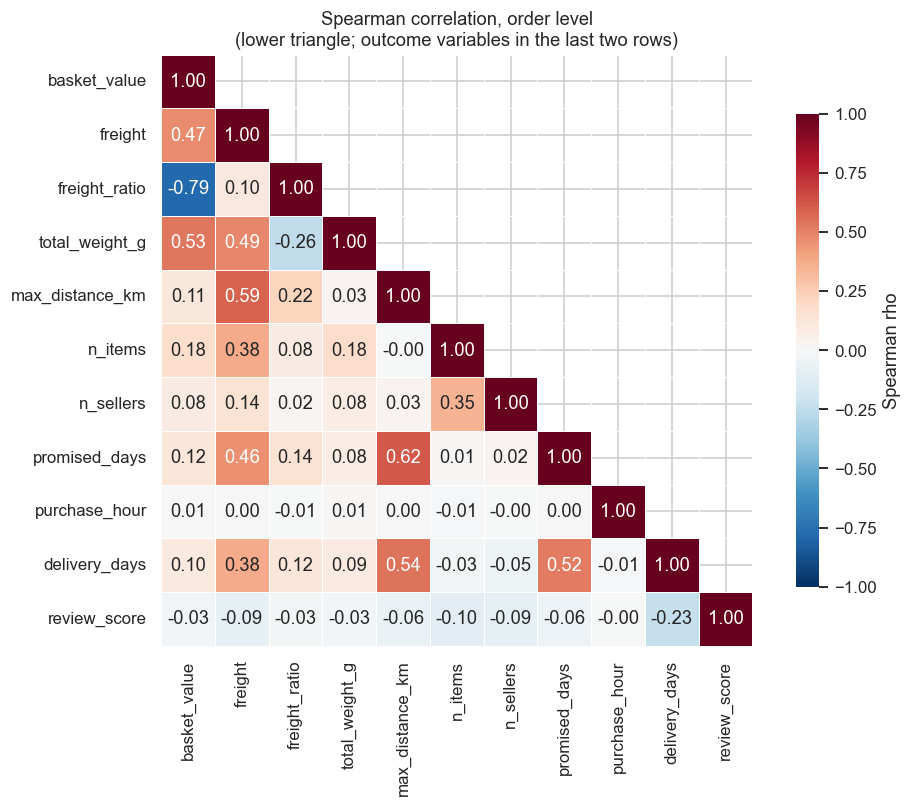

In [22]:
NUMERIC = ["basket_value", "freight", "freight_ratio", "total_weight_g", "max_distance_km",
           "n_items", "n_sellers", "promised_days", "purchase_hour",
           "delivery_days", "review_score"]

corr = order_level[NUMERIC].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"label": "Spearman rho", "shrink": .8}, ax=ax)
ax.set_title("Spearman correlation, order level\n(lower triangle; outcome variables in the last two rows)")
plt.tight_layout(); plt.show()

**Reading this matrix.** The last two rows are outcomes, not predictors. Everything above them is
knowable at purchase time, so their mutual correlations are the ones that matter for feature
selection, while their correlation *with* the outcomes is a first look at signal.

In [23]:
outcomes = ["delivery_days", "review_score"]
predictors = [c for c in NUMERIC if c not in outcomes]

rows = []
for y in outcomes:
    for x in predictors:
        d = order_level[[x, y]].dropna()
        rho, p = stats.spearmanr(d[x], d[y])
        rows.append({"outcome": y, "predictor": x, "n": len(d), "spearman_rho": rho, "p_value": p})

assoc = (pd.DataFrame(rows)
         .assign(abs_rho=lambda d: d.spearman_rho.abs())
         .sort_values(["outcome", "abs_rho"], ascending=[True, False])
         .drop(columns="abs_rho")
         .reset_index(drop=True))
assoc["spearman_rho"] = assoc.spearman_rho.round(3)
assoc["p_value"] = assoc.p_value.map(lambda v: f"{v:.1e}")
assoc

,outcome,predictor,n,spearman_rho,p_value
0,delivery_days,max_distance_km,96000,0.54,0.0e+00
1,delivery_days,promised_days,96476,0.52,0.0e+00
2,delivery_days,freight,96476,0.38,0.0e+00
3,delivery_days,freight_ratio,96476,0.12,5.7e-309
4,delivery_days,basket_value,96476,0.10,2.5e-219
5,delivery_days,total_weight_g,96476,0.09,1.1e-159
6,delivery_days,n_sellers,96476,-0.05,1.7e-50
7,delivery_days,n_items,96476,-0.03,4.9e-15
8,delivery_days,purchase_hour,96476,-0.01,5.4e-03
9,review_score,n_items,97917,-0.10,7.8e-227


**Observation.** Delivery time has two nearly tied leading correlates: shipping distance
(rho = +0.54) and the promised lead time itself (rho = +0.52), with freight third (rho = +0.38).
Distance and freight are also correlated with each other, so a model using both will split their
importance between them.

The promise being that predictive is worth dwelling on. It is not a fact about logistics — it says
Olist's own estimator already encodes most of the route and seasonality signal. That makes
*"predict the promise"* the honest baseline for the Phase 2 regression: a model has to be shown to
beat it, not merely to beat the mean.

Review score, by contrast, correlates only weakly with anything observable at purchase time — the
strongest is item count at rho = -0.10. Its real driver is the delivery experience, which is
post-outcome, so satisfaction is a materially harder target than delivery.

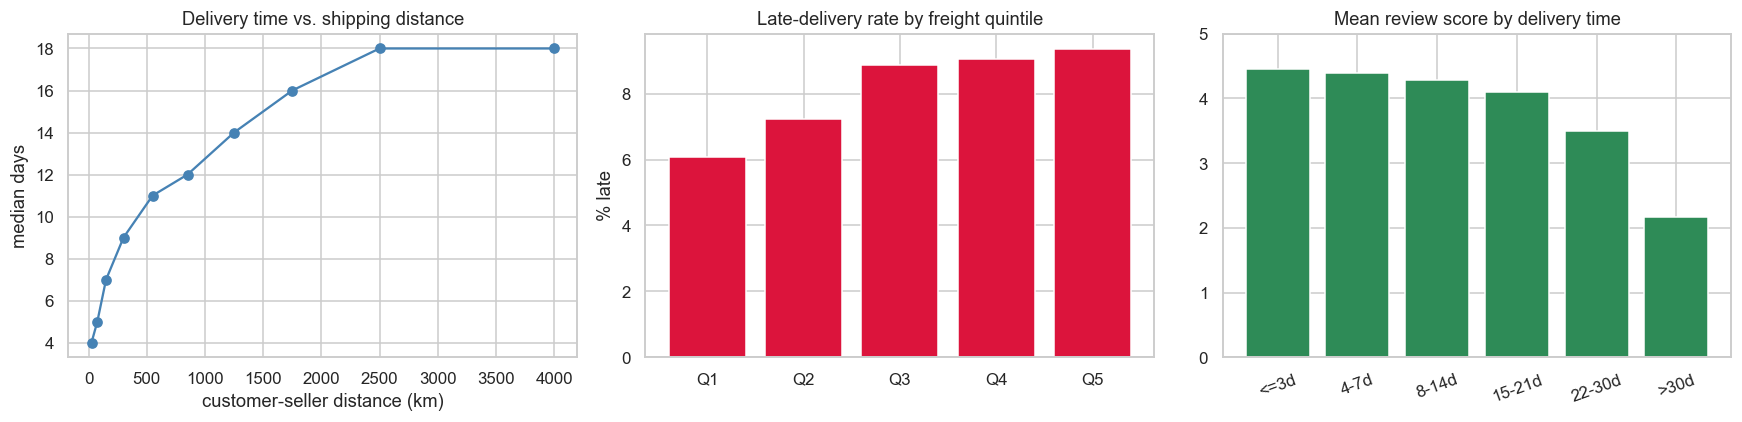

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

d = order_level.dropna(subset=["max_distance_km", "delivery_days"])
bins = [0, 50, 100, 200, 400, 700, 1000, 1500, 2000, 3000, 5000]
d = d.assign(dist_bin=pd.cut(d.max_distance_km, bins))
g = d.groupby("dist_bin", observed=True).agg(median_days=("delivery_days", "median"),
                                             late_rate=("delivery_days", "size"))
axes[0].plot([iv.mid for iv in g.index], g.median_days, marker="o", color="steelblue")
axes[0].set_title("Delivery time vs. shipping distance")
axes[0].set_xlabel("customer-seller distance (km)"); axes[0].set_ylabel("median days")

late = order_level.dropna(subset=["is_late"]).assign(
    freight_q=lambda x: pd.qcut(x.freight, 5, duplicates="drop"))
fq = late.groupby("freight_q", observed=True).is_late.mean() * 100
axes[1].bar(range(len(fq)), fq.values, color="crimson")
axes[1].set_xticks(range(len(fq)))
axes[1].set_xticklabels([f"Q{i+1}" for i in range(len(fq))])
axes[1].set_title("Late-delivery rate by freight quintile"); axes[1].set_ylabel("% late")

dr = order_level.dropna(subset=["review_score", "delivery_days"]).assign(
    bucket=lambda x: pd.cut(x.delivery_days, [-1, 3, 7, 14, 21, 30, 1000],
                            labels=["<=3d", "4-7d", "8-14d", "15-21d", "22-30d", ">30d"]))
rb = dr.groupby("bucket", observed=True).review_score.mean()
axes[2].bar(rb.index.astype(str), rb.values, color="seagreen")
axes[2].set_ylim(0, 5); axes[2].set_title("Mean review score by delivery time")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

**Observation.** All three relationships are monotone and steep enough to be worth modelling.
Delivery time rises with distance; the late rate climbs across freight quintiles; and mean review
score falls by 2.3 stars — from 4.46 to 2.17 — between the fastest and slowest delivery buckets. The last
panel is the strongest single relationship found anywhere in this notebook, and it is the reason
delivery performance — not price or assortment — is the through-line of the candidate problems in
notebooks `01`–`04`.

## 8. Key insights

**Data quality.** The nine tables join essentially without orphans. The one real gap is 775 orders
(0.8%) with no line item — almost all `unavailable` or `canceled`, yet paid and reviewed at a mean
of about 1.7 stars. They are excluded from the consolidated table by construction, so every rate
computed downstream is conditional on the order having at least one item, and that caveat belongs in
the report. Missingness elsewhere is structural, not corrupt: null delivery timestamps mean the
order never reached that stage.

**Identity.** `customer_id` is one per order; `customer_unique_id` identifies people. Repeat buying
sits near 3%, which removes churn / CLV / repeat-purchase from the realistic problem set.

**Time.** Volume grows about ninefold across the window with a single Black Friday spike that must
be a dummy rather than learned seasonality. The late-delivery rate swings fifteen-fold between
months (1.4% to 21.4%) while the promised lead time stays flat — so Phase 2 needs a time-ordered
split, not a random one; a random split would leak the calm months into the test set.

**Concentration.** Both sides of the marketplace are concentrated: three states hold most customers,
and a small minority of sellers produces half of GMV. Long-tailed categorical features will need
grouping and smoothed encodings.

**Relationships.** Shipping distance (rho = +0.54) and the promised lead time (rho = +0.52) are the
two strongest correlates of actual delivery time, with freight third. That the promise is almost as
predictive as distance makes "predict the promise" the baseline any Phase 2 regression must beat.
Review score is driven by the delivery experience rather than by anything observable at purchase
time (best purchase-time correlate: rho = -0.10), which makes it a materially harder target.

**Candidate problems this supports.** Delivery is the spine of the dataset: it has the strongest
relationships, clean pre-purchase features and a natural dual framing — will this order be late
(classification, `01`/`02`) and how long will it take (regression, `03`) — which is exactly the
pairing Phase 2 asks for. Regional demand (`04`) is viable but at a much smaller effective sample:
24 months across a handful of non-trivial states.